# 1. Seleção dos dados

Os dados selecionados foram retirados do artigo "Recovery Trends in Marine Mammal Populations" escrito por Magera et.al. O artigo analisa séries temporais de abundância populacional de 47 espécies de mamíferos marinhos. O gráfico original busca comparar o número de espécies incluídas neste estudo em comparação com o número total de espécies. Ele também faz uma separação por grupo taxonômico para mostrar quais grupos tiveram mais representação no estudo.

# 2. Gráficos propostos

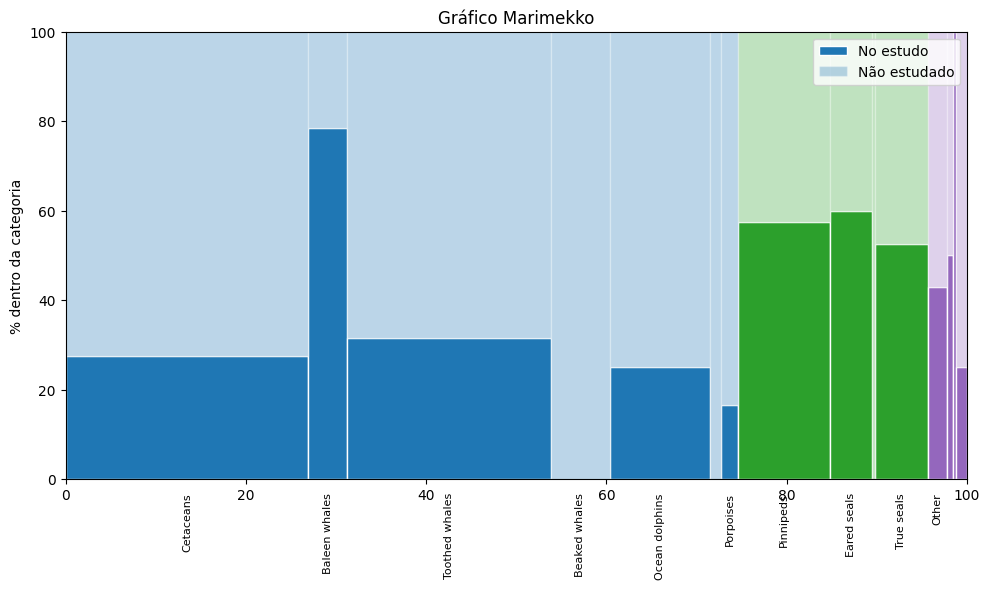

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

CORES = {
    "Cetaceans": "#1f77b4",
    "Pinnipeds": "#2ca02c",
    "Other": "#9467bd",
}

df_mari = pd.read_csv("especies_marinhas.csv")
df_mari = df_mari[df_mari["Category"] != "All"].copy()
df_mari["Color"] = df_mari["Taxonomic_Group"].map(CORES)

df_mari["Width"] = df_mari["Total_Species"] / df_mari["Total_Species"].sum() * 100
df_mari["Pct_Study"] = df_mari["Study_Species"] / df_mari["Total_Species"] * 100
df_mari["X_Left"] = df_mari["Width"].cumsum() - df_mari["Width"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(df_mari["X_Left"], df_mari["Pct_Study"], width=df_mari["Width"], align="edge", color=df_mari["Color"], edgecolor="white", label="No estudo")
ax.bar(df_mari["X_Left"], 100 - df_mari["Pct_Study"], width=df_mari["Width"], bottom=df_mari["Pct_Study"], align="edge", color=df_mari["Color"], alpha=0.3, edgecolor="white", label="Não estudado")

for _, row in df_mari[df_mari["Width"] > 1.5].iterrows():
    ax.text(row["X_Left"] + row["Width"] / 2, -3, row["Category"], rotation=90, ha="center", va="top", fontsize=8)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_ylabel("% dentro da categoria")
ax.set_title("Gráfico Marimekko")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

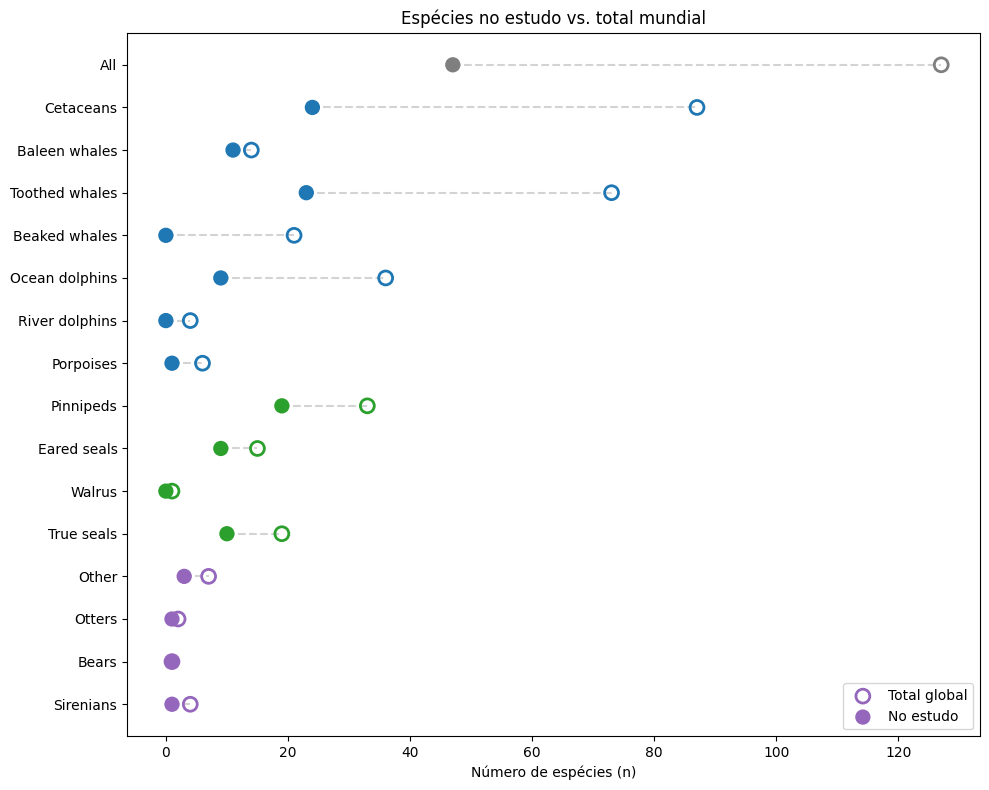

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

CORES = {
    "Cetaceans": "#1f77b4",
    "Pinnipeds": "#2ca02c",
    "Other": "#9467bd",
    "All": "#7f7f7f"
}

df = pd.read_csv("especies_marinhas.csv")
df["Color"] = df["Taxonomic_Group"].map(CORES)

df_plot = df.iloc[::-1] 

fig, ax = plt.subplots(figsize=(10, 8))
ax.hlines(df_plot["Category"], xmin=df_plot["Study_Species"], xmax=df_plot["Total_Species"], color="lightgrey", ls="--", zorder=1)
ax.scatter(df_plot["Total_Species"], df_plot["Category"], s=100, facecolors="none", edgecolors=df_plot["Color"], linewidth=2, label="Total global", zorder=2)
ax.scatter(df_plot["Study_Species"], df_plot["Category"], s=100,
           color=df_plot["Color"], label="No estudo", zorder=3)

ax.set_xlabel("Número de espécies (n)")
ax.set_title("Espécies no estudo vs. total mundial")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


Entre os dois gráficos testados o melhor para o problema sendo explorado foi o de pontos. Ele consegue abordar todas as categorias, além de comparar as proporções entre as espécies incluidas no estudo e o total.

# 3. Justificativa

1. Qual a comparação original?

O gráfico original busca comparar as espécies investigadas no estudo ao total de espécies existentes dentro deste subgrupo taxonômico.

2. O leitor precisa do valor exato?

Como o foco deste gráfico é a proporção entre o total e o incluído no estudo, o leitor não precisa de valores exatos. Portanto, usar gráficos que priorizam o proporção entre séries é o ideal para estes dados, o que motivou a escolha dos gráficos usados.

3. Quantas séries e categorias estão presentes?

O gráfico tem duas séries, os presentes no estudo e o total, e 16 categorias representando os grupos taxonômicos.

4. O formato é familiar ao público?

Sim. Tanto o gráfico de pontos é um formato comum e amplamente utilizado dentro e fora do ambiente acadêmico.

# 4. Risco de leitura e mitigação

O gráfico utilizado possue um risco de leitura baixo, abrindo mão do apelo visual por uma apresentação mais clara e precisa dos dados. No entanto, ainda é importante prezar pelo organização dos dados para tornar a leitura ainda mais fácil. No caso apresentado nesse exercício, os dados foram sempre apresentados em ordem decrescente, começando pelos grupos com o maior número de espécies.